# Analyse de la Création d'Espace — Runs-in-Behind
## Clustering Dynamique sur les Deltas de Perturbation Spatiale

**Objectif :** Caractériser les *vrais* runs-in-behind en analysant non pas l'état statique,
mais l'**évolution** des métriques spatiales entre le début et la fin du run.

Pipeline :
1. Ingénierie des variables Delta
2. Clustering K-means + CAH sur les Deltas
3. Analyse des centroïdes & seuils de filtrage
4. Visualisations (PCA, Radar Charts, Corrélations)
5. Score de Qualité Spatiale pour la vérité terrain

In [88]:
# ─────────────────────────────────────────────
# 0. CONFIGURATION & IMPORTS
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
from matplotlib.patches import FancyBboxPatch

# ── Chemins ──────────────────────────────────
DATA_PATH = r"C:\Users\arnau\Documents\projetde\runs-in-behind\outputs_spatial\runs_spatial_ALL.csv"

# ── Paramètres globaux ───────────────────────
N_CLUSTERS   = 5       # Nombre de clusters K-means (ajustable selon elbow)
RANDOM_STATE = 42
PALETTE      = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FFC107']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print("✅ Imports OK")

✅ Imports OK


---
## 1. Chargement des données

In [89]:
df = pd.read_csv(DATA_PATH)

print(f"📦 Dimensions : {df.shape[0]} runs × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes disponibles :")
for i, c in enumerate(df.columns):
    print(f"  {i:2d}. {c}")

# Aperçu rapide des colonnes spatiales
spatial_cols = [c for c in df.columns if any(k in c for k in ['sc_','inter_line','team_length'])]
print(f"\n🔍 Colonnes spatiales détectées ({len(spatial_cols)}) :")
print(df[spatial_cols].describe().round(3))

📦 Dimensions : 6909 runs × 49 colonnes

📋 Colonnes disponibles :
   0. start_frame
   1. end_frame
   2. peak_frame
   3. xID
   4. player
   5. position
   6. team
   7. possession
   8. jID
   9. x_start
  10. y_start
  11. x_end
  12. y_end
  13. x_peak
  14. y_peak
  15. peak_speed_kmh
  16. speed_category
  17. avg_velocity_kmh
  18. distance_m
  19. duration_s
  20. half
  21. location
  22. start_timecode
  23. end_timecode
  24. direction
  25. attack_sign
  26. match_id
  27. has_ball_touch
  28. sc_runner_start
  29. sc_interligne_start
  30. sc_ball_carrier_start
  31. sc_runner_mid
  32. sc_interligne_mid
  33. sc_ball_carrier_mid
  34. sc_runner_end
  35. sc_interligne_end
  36. sc_ball_carrier_end
  37. inter_line_dist_start
  38. inter_line_dist_mid
  39. inter_line_dist_end
  40. team_length_start
  41. team_length_mid
  42. team_length_end
  43. runner_to_def_dist_start
  44. runner_to_def_dist_mid
  45. runner_to_def_dist_end
  46. ball_carrier_to_def_dist_start
  47.

---
## 2. Ingénierie des Variables de Création (Deltas)

On calcule les variables de **changement** pour capturer la perturbation spatiale
induite par chaque run, plutôt que son état instantané.

In [90]:
df_feat = df.copy()

# ── 2.1 Gain net d'espace du runner ──────────────────────────────────────────
# Δ positif = le runner gagne de l'espace dans la défense
df_feat['delta_sc_runner'] = df_feat['sc_runner_end'] - df_feat['sc_runner_start']

# ── 2.2 Impact sur le bloc adverse (interligne) ───────────────────────────────
# Δ positif = le bloc se dilate (espace entre les lignes augmente)
df_feat['delta_sc_interligne'] = df_feat['sc_interligne_end'] - df_feat['sc_interligne_start']

# ── 2.3 Velocité de création d'espace ─────────────────────────────────────────
# Gain d'espace par seconde : un run court mais violent est valorisé
df_feat['space_creation_velocity'] = df_feat['delta_sc_runner'] / df_feat['duration_s'].replace(0, np.nan)

# ── 2.4 Compression défensive (évolution inter_line_dist) ─────────────────────
# Δ négatif = le bloc se rétracte → signe que le run crée une pression
df_feat['delta_inter_line_dist'] = df_feat['inter_line_dist_end'] - df_feat['inter_line_dist_start']

# ── 2.5 Variables bonus ──────────────────────────────────────────────────────
# Impact sur le porteur : est-ce un run de diversion ?
df_feat['delta_sc_ball_carrier'] = df_feat['sc_ball_carrier_end'] - df_feat['sc_ball_carrier_start']

# Évolution de la longueur de l'équipe (stretching)
df_feat['delta_team_length'] = df_feat['team_length_end'] - df_feat['team_length_start']

# Gain total (runner + interligne) : indicateur composite de perturbation
df_feat['total_space_gain'] = df_feat['delta_sc_runner'] + df_feat['delta_sc_interligne']

df_feat['delta_dist_runner_defender'] = df_feat['runner_to_def_dist_end'] - df_feat['runner_to_def_dist_start']

df_feat['delta_ball_carrier_defender'] = df_feat['ball_carrier_to_def_dist_end'] - df_feat['ball_carrier_to_def_dist_start']

# ── Résumé ───────────────────────────────────────────────────────────────────
delta_cols = [
    'delta_sc_runner', 'delta_sc_interligne', 'space_creation_velocity',
    'delta_inter_line_dist', 'delta_sc_ball_carrier', 'delta_team_length',
    'total_space_gain', 'delta_dist_runner_defender', 'delta_ball_carrier_defender'
]

print("📐 Variables Delta créées :")
print(df_feat[delta_cols].describe().round(3))

# Vérification des NaN post-création
nan_counts = df_feat[delta_cols].isna().sum()
print(f"\n⚠️  Valeurs manquantes par variable :")
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "  Aucune")

📐 Variables Delta créées :
       delta_sc_runner  delta_sc_interligne  space_creation_velocity  \
count         6878.000             6864.000                 6878.000   
mean            -1.303                2.582                   -1.736   
std            168.442               12.358                   43.507   
min          -4028.058              -74.220                 -513.783   
25%            -52.726               -4.210                  -14.862   
50%             -1.098                2.500                   -0.231   
75%             54.923                9.140                   14.514   
max            936.988               54.600                  249.115   

       delta_inter_line_dist  delta_sc_ball_carrier  delta_team_length  \
count               6878.000               6878.000           6802.000   
mean                  -1.495                 -0.336             -0.074   
std                    3.635                  4.078              5.183   
min                  -19.194

---
## 3. Préparation pour le Clustering

In [91]:
# ── 3.1 Sélection des features de clustering ─────────────────────────────────
cluster_features = [
    'delta_sc_runner',
    'delta_sc_interligne',
    'space_creation_velocity',
    'delta_inter_line_dist',
    'delta_sc_ball_carrier',
    'delta_team_length',
    'delta_dist_runner_defender',
    'delta_ball_carrier_defender'
]

# ── 3.2 Nettoyage : suppression des lignes avec NaN ──────────────────────────
# FIXED: cluster_features is a subset of delta_cols — combining them created
# duplicate columns, making X_scaled shape (n, 12) instead of (n, 6).
# Using delta_cols alone is sufficient (it already contains all cluster_features).
df_clean = df_feat[delta_cols + ['player', 'team', 'match_id',
                    'duration_s', 'distance_m', 'peak_speed_kmh',
                    'sc_runner_start', 'sc_runner_end',
                    'sc_interligne_start', 'sc_interligne_end',
                    'sc_ball_carrier_start', 'sc_ball_carrier_end',
                    'total_space_gain', 'has_ball_touch',
                    # Timecodes
                    'start_timecode', 'end_timecode',
                    'start_frame', 'end_frame', 'peak_frame',
                    'half']].dropna(subset=delta_cols)

print(f"✅ Runs conservés après nettoyage : {len(df_clean)} / {len(df_feat)}")

# ── 3.3 Standardisation ──────────────────────────────────────────────────────
scaler  = StandardScaler()
X       = df_clean[cluster_features].values
X_scaled = scaler.fit_transform(X)

print(f"\n📊 Matrice de clustering : {X_scaled.shape}")
print(pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2))

✅ Runs conservés après nettoyage : 6789 / 6909

📊 Matrice de clustering : (6789, 8)
       delta_sc_runner  delta_sc_interligne  space_creation_velocity  \
count          6789.00              6789.00                  6789.00   
mean              0.00                 0.00                    -0.00   
std               1.00                 1.00                     1.00   
min             -23.97                -6.21                   -11.78   
25%              -0.31                -0.55                    -0.30   
50%               0.00                -0.01                     0.03   
75%               0.33                 0.53                     0.37   
max               5.59                 4.21                     5.77   

       delta_inter_line_dist  delta_sc_ball_carrier  delta_team_length  \
count                6789.00                6789.00            6789.00   
mean                    0.00                  -0.00               0.00   
std                     1.00                 

---
## 4. Choix du Nombre de Clusters — Méthode du Coude + Silhouette

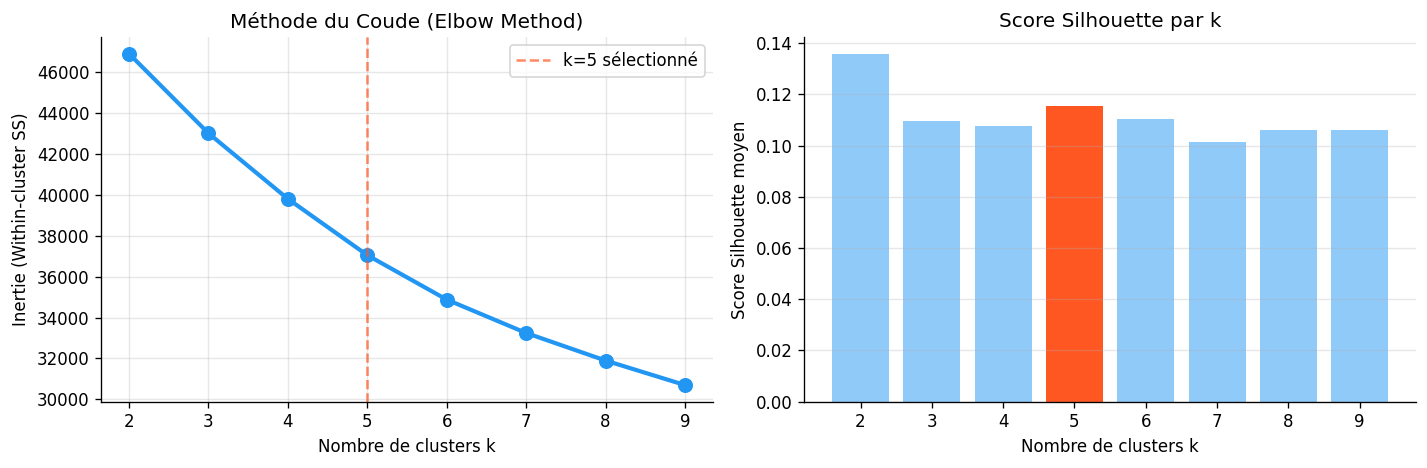

🏆 k optimal selon Silhouette : 2  (score=0.136)
   k retenu pour la suite     : 5


In [92]:
inertias    = []
sil_scores  = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe d'inertie (Elbow)
axes[0].plot(K_range, inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
axes[0].axvline(x=N_CLUSTERS, color='#FF5722', linestyle='--', alpha=0.7,
                label=f'k={N_CLUSTERS} sélectionné')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (Within-cluster SS)')
axes[0].set_title('Méthode du Coude (Elbow Method)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Score Silhouette
axes[1].bar(K_range, sil_scores, color=['#FF5722' if k == N_CLUSTERS else '#90CAF9' for k in K_range])
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score Silhouette moyen')
axes[1].set_title('Score Silhouette par k')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"🏆 k optimal selon Silhouette : {best_k}  (score={max(sil_scores):.3f})")
print(f"   k retenu pour la suite     : {N_CLUSTERS}")

---
## 5. Clustering K-Means sur les Deltas

In [93]:
# ── 5.1 Ajustement K-Means ───────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=30, max_iter=500)
df_clean['cluster_km'] = kmeans.fit_predict(X_scaled)

# ── 5.2 Identifier le cluster "Créateur" ─────────────────────────────────────
# Le cluster créateur = celui dont le centroïde a le plus grand delta_sc_runner
centroids_real = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df   = pd.DataFrame(centroids_real, columns=cluster_features)
creator_cluster_km = centroids_df['delta_sc_runner'].idxmax()

print(f"✅ K-Means terminé. Distribution des clusters :")
print(df_clean['cluster_km'].value_counts().sort_index())
print(f"\n🚀 Cluster 'Créateur' (max Δsc_runner) : Cluster {creator_cluster_km}")

# ── 5.3 Centroïdes en unités réelles ─────────────────────────────────────────
print("\n📍 Centroïdes K-Means (unités réelles) :")
print(centroids_df.round(3).to_string())

✅ K-Means terminé. Distribution des clusters :
cluster_km
0     780
1     580
2    2059
3     684
4    2686
Name: count, dtype: int64

🚀 Cluster 'Créateur' (max Δsc_runner) : Cluster 0

📍 Centroïdes K-Means (unités réelles) :
   delta_sc_runner  delta_sc_interligne  space_creation_velocity  delta_inter_line_dist  delta_sc_ball_carrier  delta_team_length  delta_dist_runner_defender  delta_ball_carrier_defender
0          264.132                9.643                   65.679                 -2.417                  0.114             -1.143                       2.435                        0.066
1            0.261               -2.562                   -0.838                 -0.843                 -7.228              2.276                      -0.954                       -9.782
2            9.942               -1.328                    2.906                  0.950                  1.319              1.810                       1.502                        1.937
3         -294.445        

---
## 6. CAH — Classification Ascendante Hiérarchique

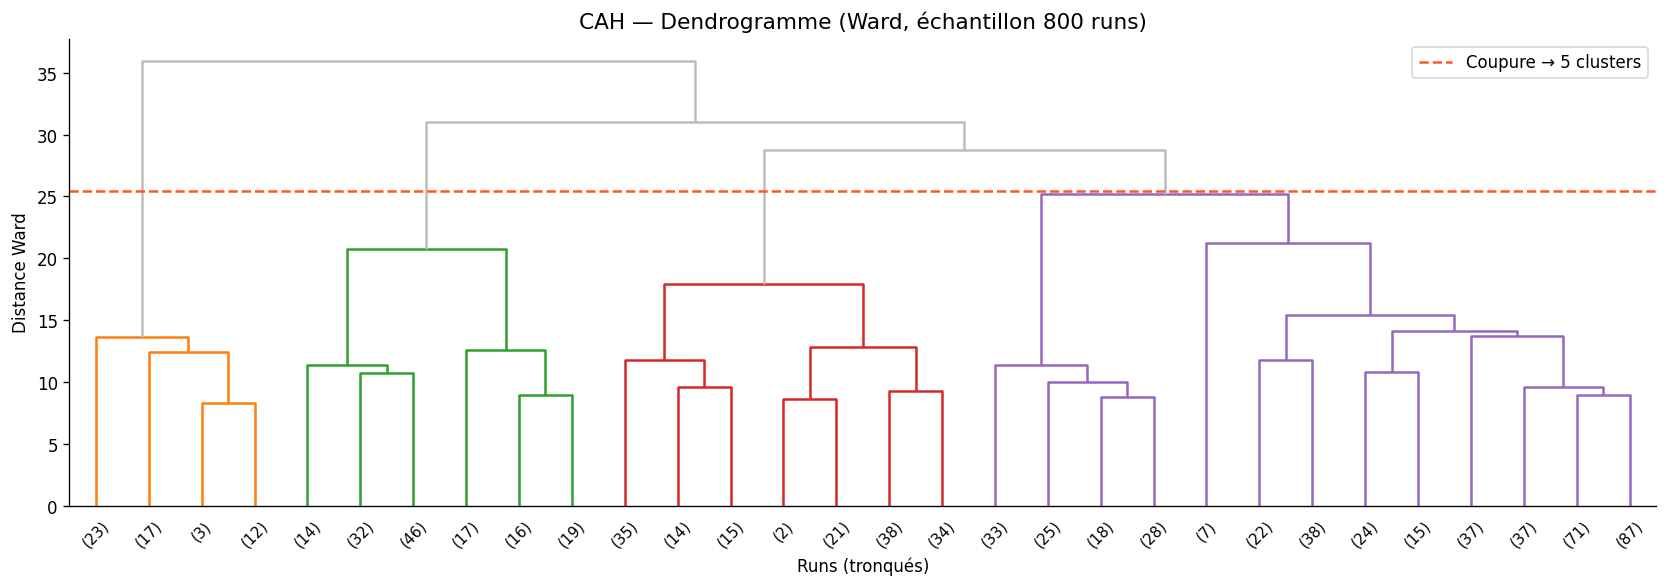


✅ CAH terminée. Distribution :
cluster_cah
0     536
1    1229
2    1380
3     994
4    2650
Name: count, dtype: int64

🚀 Cluster Créateur CAH : 1


In [94]:
# ── 6.1 Linkage sur un échantillon (CAH coûteuse sur gros datasets) ───────────
sample_size = min(800, len(X_scaled))
rng = np.random.default_rng(RANDOM_STATE)
idx_sample = rng.choice(len(X_scaled), size=sample_size, replace=False)
X_sample   = X_scaled[idx_sample]

Z = linkage(X_sample, method='ward', metric='euclidean')

# ── 6.2 Dendrogramme ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax, truncate_mode='lastp', p=30,
    leaf_rotation=45, leaf_font_size=9,
    color_threshold=0.7 * max(Z[:, 2]),
    above_threshold_color='#BDBDBD'
)
ax.axhline(y=Z[-(N_CLUSTERS-1), 2] * 1.01, color='#FF5722',
           linestyle='--', label=f'Coupure → {N_CLUSTERS} clusters')
ax.set_title('CAH — Dendrogramme (Ward, échantillon 800 runs)', fontsize=13)
ax.set_xlabel('Runs (tronqués)')
ax.set_ylabel('Distance Ward')
ax.legend()
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()

# ── 6.3 Assignation CAH à l'ensemble du dataset ──────────────────────────────
# On utilise les centroïdes CAH (médoïdes approchés) via fcluster + assign nearest
labels_sample = fcluster(Z, N_CLUSTERS, criterion='maxclust') - 1  # 0-indexed

# Calculer les centroïdes de l'échantillon
cah_centers = np.array([
    X_sample[labels_sample == k].mean(axis=0)
    for k in range(N_CLUSTERS)
])

# Assigner chaque run au centroïde CAH le plus proche
distances_to_centers = cdist(X_scaled, cah_centers, metric='euclidean')
df_clean['cluster_cah'] = distances_to_centers.argmin(axis=1)

# Cluster créateur CAH
cah_centers_real = scaler.inverse_transform(cah_centers)
cah_df = pd.DataFrame(cah_centers_real, columns=cluster_features)
creator_cluster_cah = cah_df['delta_sc_runner'].idxmax()

print(f"\n✅ CAH terminée. Distribution :")
print(df_clean['cluster_cah'].value_counts().sort_index())
print(f"\n🚀 Cluster Créateur CAH : {creator_cluster_cah}")

---
## 7. Analyse des Centroïdes & Seuils de Filtrage

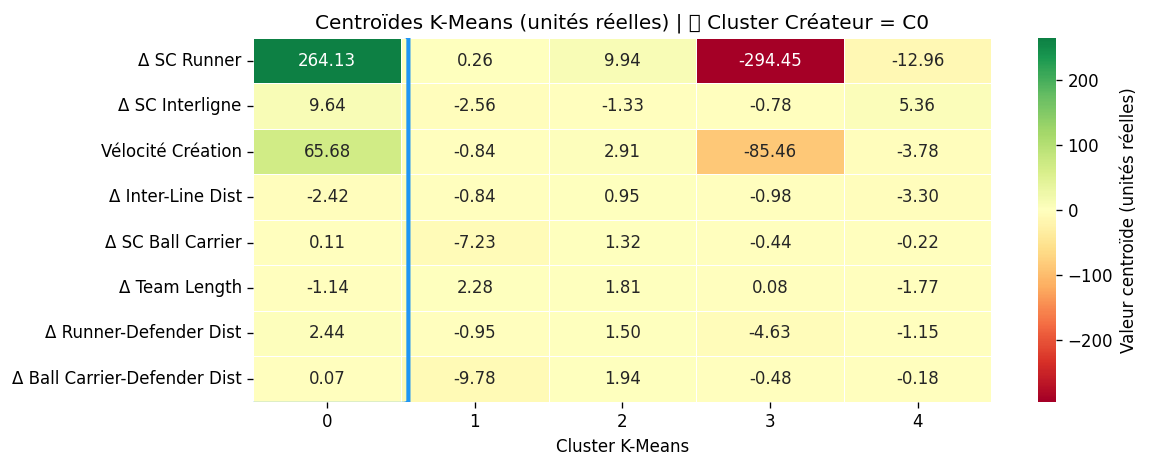

In [95]:
# ── 7.1 Heatmap des centroïdes (K-Means) ─────────────────────────────────────
labels_feat = [
    'Δ SC Runner', 'Δ SC Interligne',
    'Vélocité Création', 'Δ Inter-Line Dist',
    'Δ SC Ball Carrier', 'Δ Team Length',
    'Δ Runner-Defender Dist', 'Δ Ball Carrier-Defender Dist'
]

fig, ax = plt.subplots(figsize=(10, 4))
hm = sns.heatmap(
    centroids_df.rename(columns=dict(zip(cluster_features, labels_feat))).T,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Valeur centroïde (unités réelles)'}
)
ax.set_xlabel('Cluster K-Means')
ax.set_title('Centroïdes K-Means — Valeurs en Unités Réelles', fontsize=13, pad=12)

# Encadrer le cluster créateur
rect = FancyBboxPatch(
    (creator_cluster_km, 0), 1, len(cluster_features),
    boxstyle='round,pad=0.05',
    linewidth=2.5, edgecolor='#2196F3', facecolor='none',
    transform=ax.transData
)
ax.add_patch(rect)
ax.set_title(
    f'Centroïdes K-Means (unités réelles) | 🚀 Cluster Créateur = C{creator_cluster_km}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('fig_centroids_heatmap.png', bbox_inches='tight')
plt.show()

In [96]:
# ── 7.2 Seuils statistiques pour filtrage des vrais runs ─────────────────────
print("═" * 60)
print("  SEUILS DE FILTRAGE — Basés sur les Quartiles")
print("═" * 60)

thresholds = {}
key_vars = ['delta_sc_runner', 'delta_sc_interligne', 'space_creation_velocity', 'total_space_gain', 'delta_dist_runner_defender', 'delta_ball_carrier_defender']
var_labels = ['Δ SC Runner', 'Δ SC Interligne', 'Vélocité Création', 'Gain Total', 'Δ Runner-Defender Dist', 'Δ Ball Carrier-Defender Dist']

for var, label in zip(key_vars, var_labels):
    q25, q50, q75 = df_clean[var].quantile([0.25, 0.50, 0.75]).values
    thresholds[var] = {'Q25': q25, 'Q50': q50, 'Q75': q75}
    print(f"\n📐 {label} ({var})")
    for var, label in zip(key_vars, var_labels):
        q25, q50, q75 = df_clean[var].quantile([0.25, 0.50, 0.75]).values
        q25, q50, q75 = [float(np.asarray(x).ravel()[0]) for x in (q25, q50, q75)]
        thresholds[var] = {'Q25': q25, 'Q50': q50, 'Q75': q75}
        print(f"\n📐 {label} ({var})")
        print(f"   Q25 (minimal)  : {q25:+.3f}")
        print(f"   Q50 (médiane)  : {q50:+.3f}")
        print(f"   Q75 (fort)     : {q75:+.3f}  ← seuil recommandé Top 25%")
    print(f"   Q50 (médiane)  : {q50:+.3f}")
    print(f"   Q75 (fort)     : {q75:+.3f}  ← seuil recommandé Top 25%")

# Créer un flag "run créateur" multi-critères
df_clean['is_creator_run'] = (
    (df_clean['delta_sc_runner']   >= thresholds['delta_sc_runner']['Q75']) &
    (df_clean['space_creation_velocity'] >= thresholds['space_creation_velocity']['Q50'])
)

n_creator = df_clean['is_creator_run'].sum()
pct = n_creator / len(df_clean) * 100
print(f"\n\n🎯 Runs 'Créateurs' identifiés (Δsc_runner > Q75 ET velocité > Q50) :")
print(f"   {n_creator} runs  ({pct:.1f}% du total)")

════════════════════════════════════════════════════════════
  SEUILS DE FILTRAGE — Basés sur les Quartiles
════════════════════════════════════════════════════════════

📐 Δ SC Runner (delta_sc_runner)

📐 Δ SC Runner (delta_sc_runner)
   Q25 (minimal)  : -52.726
   Q50 (médiane)  : -1.098
   Q75 (fort)     : +53.825  ← seuil recommandé Top 25%

📐 Δ SC Interligne (delta_sc_interligne)
   Q25 (minimal)  : -4.240
   Q50 (médiane)  : +2.430
   Q75 (fort)     : +9.080  ← seuil recommandé Top 25%

📐 Vélocité Création (space_creation_velocity)
   Q25 (minimal)  : -14.875
   Q50 (médiane)  : -0.250
   Q75 (fort)     : +14.502  ← seuil recommandé Top 25%

📐 Gain Total (total_space_gain)
   Q25 (minimal)  : -53.008
   Q50 (médiane)  : +2.159
   Q75 (fort)     : +58.893  ← seuil recommandé Top 25%

📐 Δ Runner-Defender Dist (delta_dist_runner_defender)
   Q25 (minimal)  : -2.335
   Q50 (médiane)  : -0.186
   Q75 (fort)     : +1.840  ← seuil recommandé Top 25%

📐 Δ Ball Carrier-Defender Dist (delta

---
## 8. PCA — Visualisation 2D des Clusters

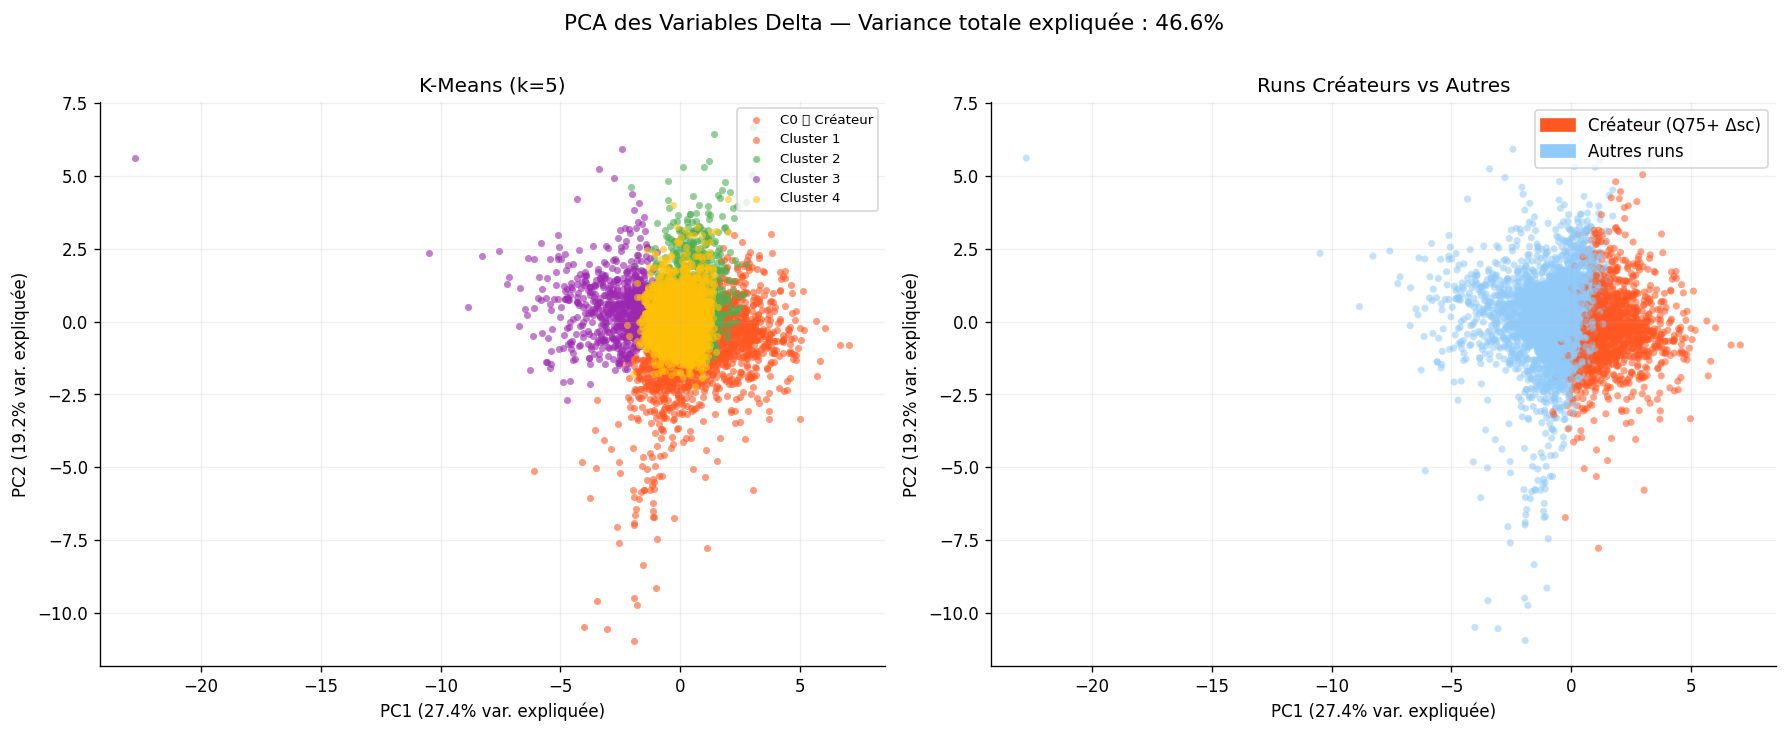


📊 Contributions PCA (loadings) :
                                PC1    PC2
Δ SC Runner                   0.626 -0.161
Δ SC Interligne               0.194  0.002
Vélocité Création             0.627 -0.148
Δ Inter-Line Dist            -0.017  0.113
Δ SC Ball Carrier             0.135  0.670
Δ Team Length                -0.033 -0.180
Δ Runner-Defender Dist        0.380  0.048
Δ Ball Carrier-Defender Dist  0.120  0.675


In [97]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax_idx, (col, title) in enumerate([
    ('cluster_km',   f'K-Means (k={N_CLUSTERS})'),
    ('is_creator_run', 'Runs Créateurs vs Autres')
]):
    ax = axes[ax_idx]
    labels = df_clean[col]

    if col == 'is_creator_run':
        colors  = labels.map({True: '#FF5722', False: '#90CAF9'})
        scatter = ax.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=colors, s=18, alpha=0.55, linewidths=0
        )
        patches = [
            mpatches.Patch(color='#FF5722', label='Créateur (Q75+ Δsc)'),
            mpatches.Patch(color='#90CAF9', label='Autres runs')
        ]
        ax.legend(handles=patches, loc='upper right')
    else:
        unique_labels = sorted(labels.unique())
        for i, lab in enumerate(unique_labels):
            mask = labels == lab
            color = '#FF5722' if lab == creator_cluster_km else PALETTE[i % len(PALETTE)]
            label_str = f'C{lab} 🚀 Créateur' if lab == creator_cluster_km else f'Cluster {lab}'
            ax.scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                s=18, alpha=0.6, color=color,
                label=label_str, linewidths=0
            )
        ax.legend(loc='upper right', fontsize=8)

    ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% var. expliquée)')
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% var. expliquée)')
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.2)

fig.suptitle(
    f'PCA des Variables Delta — Variance totale expliquée : {sum(var_explained):.1f}%',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('fig_pca_clusters.png', bbox_inches='tight')
plt.show()

# Contribution des variables aux composantes
loadings = pd.DataFrame(
    pca.components_.T,
    index=labels_feat,
    columns=['PC1', 'PC2']
).round(3)
print("\n📊 Contributions PCA (loadings) :")
print(loadings)

---
## 9. Radar Charts — Évolution Start → End par Cluster

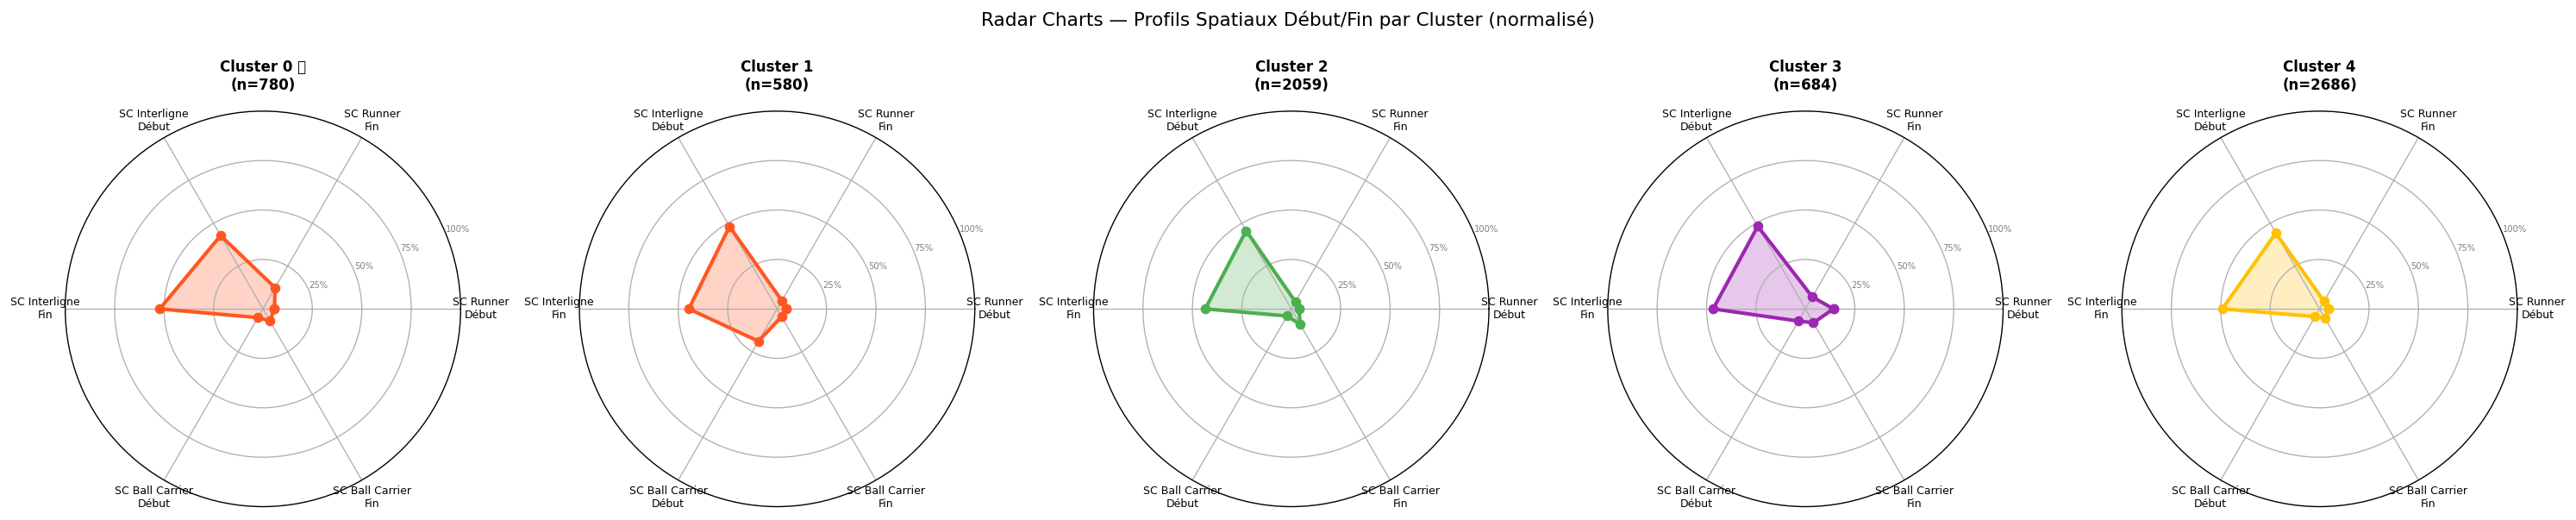

In [98]:
radar_vars   = ['sc_runner_start', 'sc_runner_end',
                'sc_interligne_start', 'sc_interligne_end',
                'sc_ball_carrier_start', 'sc_ball_carrier_end']
radar_labels = ['SC Runner\nDébut', 'SC Runner\nFin',
                'SC Interligne\nDébut', 'SC Interligne\nFin',
                'SC Ball Carrier\nDébut', 'SC Ball Carrier\nFin']

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermeture

fig, axes = plt.subplots(
    1, N_CLUSTERS,
    subplot_kw=dict(polar=True),
    figsize=(5 * N_CLUSTERS, 5)
)

for k in range(N_CLUSTERS):
    ax = axes[k]
    subset = df_clean[df_clean['cluster_km'] == k]
    means  = subset[radar_vars].mean().values

    # Normaliser sur [0,1] pour la lisibilité du radar
    global_means = df_clean[radar_vars].max().values
    vals_norm    = (means / (global_means + 1e-9)).tolist()
    vals_norm   += vals_norm[:1]

    color = '#FF5722' if k == creator_cluster_km else PALETTE[k % len(PALETTE)]
    ax.plot(angles, vals_norm, 'o-', linewidth=2.5, color=color)
    ax.fill(angles, vals_norm, alpha=0.25, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=6, color='grey')

    title = f"Cluster {k}" + (" 🚀" if k == creator_cluster_km else "")
    ax.set_title(title + f"\n(n={len(subset)})", size=10, pad=15, fontweight='bold')

fig.suptitle('Radar Charts — Profils Spatiaux Début/Fin par Cluster (normalisé)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_radar_clusters.png', bbox_inches='tight')
plt.show()

---
## 10. Matrice de Corrélation — Gain Runner vs Perte Ball Carrier

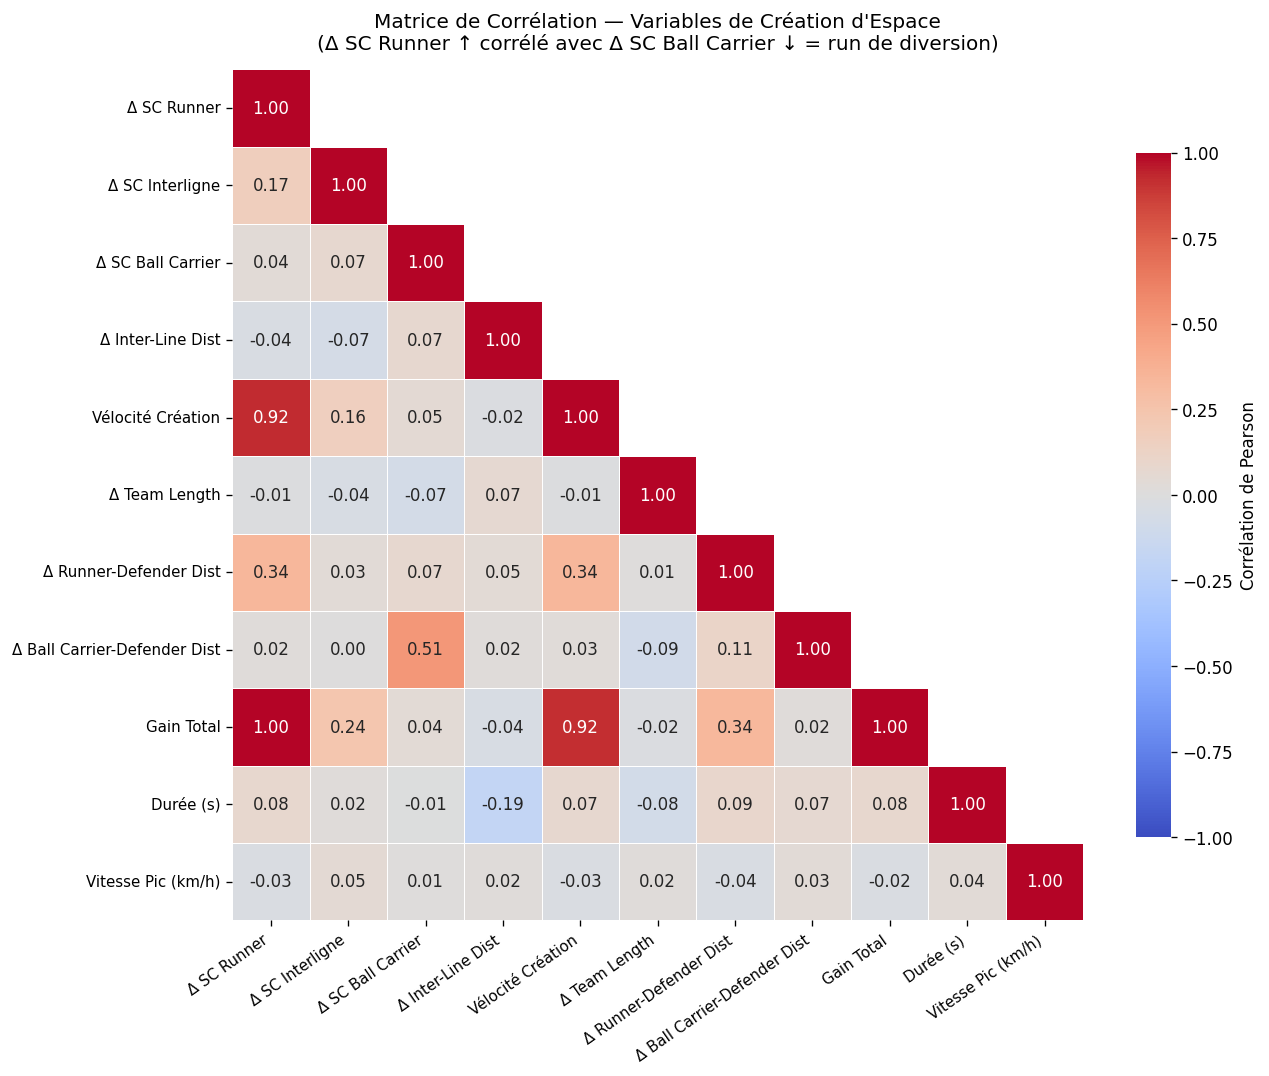


🔗 Corrélation Δsc_runner ~ Δsc_ball_carrier : r = +0.036
   → Corrélation faible : les deux sont indépendants dans ce corpus


In [99]:
corr_cols = [
    'delta_sc_runner', 'delta_sc_interligne',
    'delta_sc_ball_carrier', 'delta_inter_line_dist',
    'space_creation_velocity', 'delta_team_length',
    'delta_dist_runner_defender', 'delta_ball_carrier_defender',
    'total_space_gain', 'duration_s', 'peak_speed_kmh'
]

corr_labels = [
    'Δ SC Runner', 'Δ SC Interligne',
    'Δ SC Ball Carrier', 'Δ Inter-Line Dist',
    'Vélocité Création', 'Δ Team Length',
    'Δ Runner-Defender Dist', 'Δ Ball Carrier-Defender Dist',
    'Gain Total', 'Durée (s)', 'Vitesse Pic (km/h)'
]

corr_matrix = df_clean[corr_cols].corr()
corr_matrix = corr_matrix.loc[
    ~corr_matrix.index.duplicated(),
    ~corr_matrix.columns.duplicated()
]
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    mask=mask, square=True, linewidths=0.4,
    ax=ax, cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'}
)
ax.set_title(
    'Matrice de Corrélation — Variables de Création d\'Espace\n'
    '(Δ SC Runner ↑ corrélé avec Δ SC Ball Carrier ↓ = run de diversion)',
    fontsize=12, pad=12
)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

# Focus : corrélation delta_sc_runner vs delta_sc_ball_carrier
r_diversion = df_clean['delta_sc_runner'].corr(df_clean['delta_sc_ball_carrier'])
print(f"\n🔗 Corrélation Δsc_runner ~ Δsc_ball_carrier : r = {r_diversion:+.3f}")
if r_diversion < -0.15:
    print("   → Corrélation NÉGATIVE : un gain d'espace du runner tend à compresser")
    print("     l'espace du porteur (run de diversion confirmé statistiquement)")
elif r_diversion > 0.15:
    print("   → Corrélation POSITIVE : runner et porteur gagnent de l'espace ensemble")
else:
    print("   → Corrélation faible : les deux sont indépendants dans ce corpus")

---
## 11. Score de Qualité Spatiale — Préparation à la Vérité Terrain

In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# SCORE DE QUALITÉ SPATIALE (SQS)
#
# Formule composite pondérée (poids ajustables) :
#   SQS = w1 * rank(Δsc_runner)
#       + w2 * rank(Δsc_interligne)
#       + w3 * rank(space_creation_velocity)
#       + w4 * rank(-Δsc_ball_carrier)   # diversion : moins le porteur a d'espace...
#       + w5 * rank(-Δinter_line_dist)   # bloc compressé = pressure exercée
# ─────────────────────────────────────────────────────────────────────────────

WEIGHTS = {
    'delta_sc_runner'         :  0.15,   # Gain direct du runner
    'delta_sc_interligne'     :  0.15,   # Impact sur le bloc
    'space_creation_velocity' :  0.05,   # Efficacité temporelle
    'delta_sc_ball_carrier'   : -0.10,   # Diversion (inversé)
    'delta_inter_line_dist'   : -0.15,   # Compression (inversé)
    'delta_dist_runner_defender'   : 0.15,   # Pression (inversé)
    'delta_ball_carrier_defender'   : 0.15,   # Pression (inversé)

}

df_score = df_clean.copy()

# Rang centile [0, 1] pour chaque variable
score_sum = np.zeros(len(df_score))
for var, w in WEIGHTS.items():
    rank_pct = df_score[var].rank(pct=True)
    if w < 0:
        rank_pct = 1 - rank_pct  # Inverser le rang
    score_sum += abs(w) * rank_pct

# Normaliser SQS sur [0, 100]
df_score['SQS'] = (score_sum / sum(abs(v) for v in WEIGHTS.values())) * 100

# ── Catégories de qualité ─────────────────────────────────────────────────────
def sqs_label(score):
    if score >= 80: return '🔥 Elite'
    if score >= 65: return '✅ Fort'
    if score >= 50: return '📊 Moyen'
    if score >= 35: return '⚠️  Faible'
    return '❌ Pauvre'

df_score['SQS_label'] = df_score['SQS'].apply(sqs_label)

# ── Top 20 runs ───────────────────────────────────────────────────────────────
top20 = df_score.nlargest(20, 'SQS')[[
    'player', 'team', 'match_id', 'duration_s', 'peak_speed_kmh',
    'delta_sc_runner', 'delta_sc_interligne', 'space_creation_velocity',
    'delta_dist_runner_defender', 'delta_ball_carrier_defender',
    'SQS', 'SQS_label', 'cluster_km'
]].reset_index(drop=True)

print("🏆 TOP 20 RUNS — Classement par Score de Qualité Spatiale (SQS)")
print("═" * 70)
print(top20.to_string(index=True))

# Distribution SQS
print("\n📊 Distribution du SQS :")
print(df_score['SQS_label'].value_counts().to_string())

🏆 TOP 20 RUNS — Classement par Score de Qualité Spatiale (SQS)
══════════════════════════════════════════════════════════════════════
              player                  team match_id  duration_s  peak_speed_kmh  delta_sc_runner  delta_sc_interligne  space_creation_velocity  delta_dist_runner_defender  delta_ball_carrier_defender        SQS SQS_label  cluster_km
0          C. Klarer    Fortuna Düsseldorf   J03WPY        8.40       14.466194       429.498462                31.93                51.130769                       5.504                        3.687  92.858955   🔥 Elite           0
1       M. Karbownik    Fortuna Düsseldorf   J03WR9        7.76       17.560451       266.926154                11.03                34.397700                      12.425                        7.051  91.429355   🔥 Elite           0
2       M. Karbownik    Fortuna Düsseldorf   J03WOY        6.28       18.925991       272.418462                 8.62                43.378736                       4.

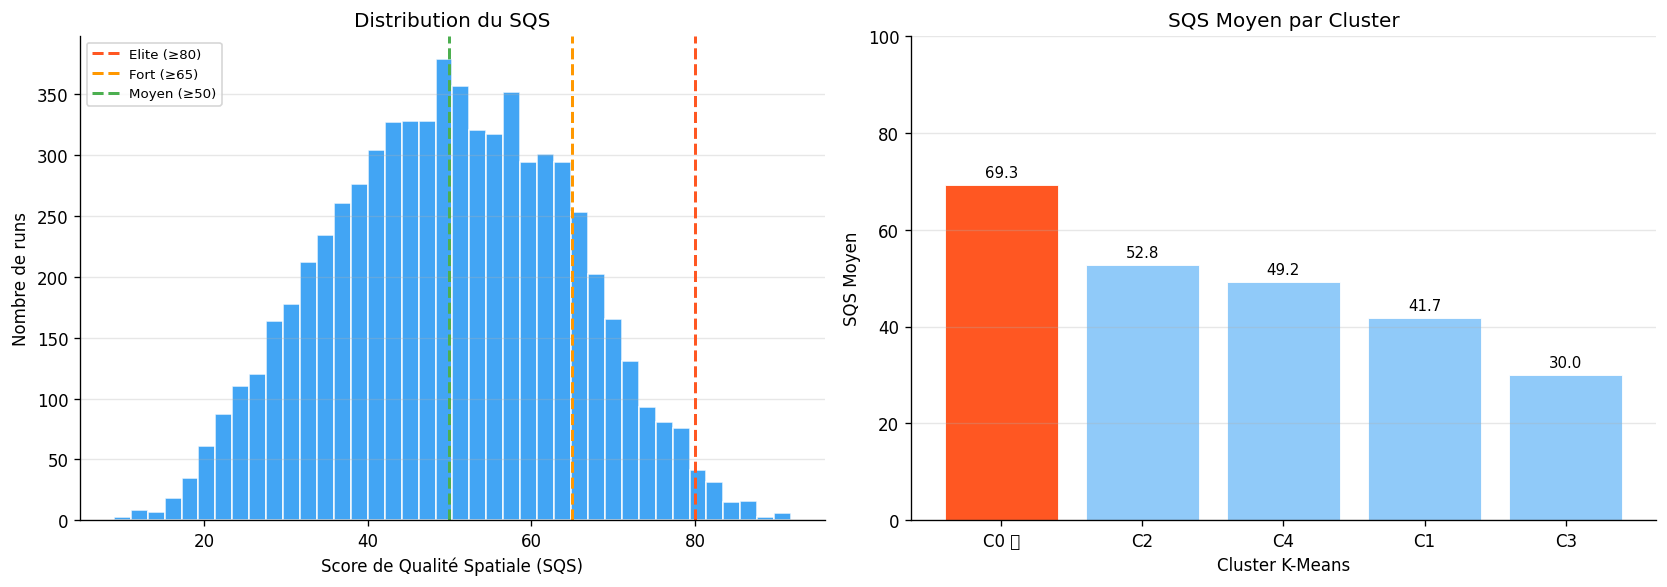

In [101]:
# ── Visualisation distribution SQS ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme SQS
ax = axes[0]
ax.hist(df_score['SQS'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
for pct, color, lbl in [
    (80, '#FF5722', 'Elite (≥80)'),
    (65, '#FF9800', 'Fort (≥65)'),
    (50, '#4CAF50', 'Moyen (≥50)')
]:
    ax.axvline(x=pct, color=color, linestyle='--', linewidth=1.8, label=lbl)
ax.set_xlabel('Score de Qualité Spatiale (SQS)')
ax.set_ylabel('Nombre de runs')
ax.set_title('Distribution du SQS')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# SQS moyen par cluster K-Means
ax = axes[1]
cluster_sqs = df_score.groupby('cluster_km')['SQS'].mean().sort_values(ascending=False)
colors_bar  = ['#FF5722' if k == creator_cluster_km else '#90CAF9' for k in cluster_sqs.index]
bars = ax.bar(
    [f'C{k}' + (' 🚀' if k == creator_cluster_km else '') for k in cluster_sqs.index],
    cluster_sqs.values,
    color=colors_bar, edgecolor='white', linewidth=0.5
)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlabel('Cluster K-Means')
ax.set_ylabel('SQS Moyen')
ax.set_title('SQS Moyen par Cluster')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_sqs_distribution.png', bbox_inches='tight')
plt.show()

---
## 12. Export — Fichier enrichi pour la Vérité Terrain

In [110]:
# ── Colonnes à exporter ───────────────────────────────────────────────────────
export_cols = [
    # Identifiants
    'player', 'team', 'match_id', 'has_ball_touch',
    # Timecodes & frames
    'start_timecode', 'end_timecode',
    'start_frame', 'end_frame', 'peak_frame', 'half',
    # Cinématique
    'duration_s', 'distance_m', 'peak_speed_kmh', 'avg_velocity_kmh',
    # Variables brutes
    'sc_runner_start', 'sc_runner_end',
    'sc_interligne_start', 'sc_interligne_end',
    'sc_ball_carrier_start', 'sc_ball_carrier_end',
    # Deltas
    'delta_sc_runner', 'delta_sc_interligne', 'delta_sc_ball_carrier',
    'delta_inter_line_dist', 'delta_team_length',
    'space_creation_velocity', 'total_space_gain',
    # Clustering
    'cluster_km', 'cluster_cah', 'is_creator_run',
    # Score
    'SQS', 'SQS_label'
]

# Filtrer uniquement les colonnes disponibles
export_cols_avail = [c for c in export_cols if c in df_score.columns]

output_path = 'runs_spatial_scored.csv'
df_score[export_cols_avail].sort_values('SQS', ascending=False).to_csv(output_path, index=False)

print(f"✅ Fichier exporté : {output_path}")
print(f"   Runs exportés  : {len(df_score)}")
print(f"   Colonnes       : {len(export_cols_avail)}")
print()
print("📋 Prochaine étape — Comparaison avec la Vérité Terrain :")
print("   1. Charger votre vérité terrain (e.g. labels manuels vrais/faux)")
print("   2. Faire un merge sur player + match_id + timecode")
print("   3. Calculer AUC / Precision-Recall du SQS comme score de classement")
print("   4. Optimiser les poids WEIGHTS pour maximiser la concordance")

✅ Fichier exporté : runs_spatial_scored.csv
   Runs exportés  : 6789
   Colonnes       : 31

📋 Prochaine étape — Comparaison avec la Vérité Terrain :
   1. Charger votre vérité terrain (e.g. labels manuels vrais/faux)
   2. Faire un merge sur player + match_id + timecode
   3. Calculer AUC / Precision-Recall du SQS comme score de classement
   4. Optimiser les poids WEIGHTS pour maximiser la concordance


---
## 13. Synthèse — Paramètres de Filtrage Recommandés

Les seuils ci-dessous peuvent être utilisés dans un pipeline de filtrage
pour valider automatiquement qu'un run-in-behind prédit est un **vrai run créateur d'espace**.

In [111]:
print("═" * 65)
print("  PARAMÈTRES DE FILTRAGE RECOMMANDÉS — RUNS-IN-BEHIND CRÉATEURS")
print("═" * 65)

for var, th in thresholds.items():
    label = dict(zip(key_vars, var_labels))[var]
    print(f"\n▸ {label}")
    print(f"  Filtre minimal  (Q25) : ≥ {th['Q25']:+.3f}")
    print(f"  Filtre modéré   (Q50) : ≥ {th['Q50']:+.3f}")
    print(f"  Filtre strict   (Q75) : ≥ {th['Q75']:+.3f}  ← recommandé 'vrai run'")

print("\n───────────────────────────────────────────────────────────────")
print("  FILTRE COMPOSITE (exemple) :")
print(f"  delta_sc_runner ≥ {thresholds['delta_sc_runner']['Q75']:+.3f}")
print(f"  AND space_creation_velocity ≥ {thresholds['space_creation_velocity']['Q50']:+.3f}")
print(f"  → Retient {df_clean['is_creator_run'].sum()} runs ({df_clean['is_creator_run'].mean()*100:.1f}%)")

print("\n───────────────────────────────────────────────────────────────")
print("  SCORE SQS — Seuils de catégorisation :")
print("  ≥ 80  → 🔥 Elite  : candidat quasi-certain pour vérité terrain")
print("  65–80 → ✅ Fort   : probablement un vrai run")
print("  50–65 → 📊 Moyen  : ambigu, à vérifier manuellement")
print("  < 50  → ❌ Faible : likely faux positif")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  PARAMÈTRES DE FILTRAGE RECOMMANDÉS — RUNS-IN-BEHIND CRÉATEURS
═════════════════════════════════════════════════════════════════

▸ Δ SC Runner
  Filtre minimal  (Q25) : ≥ -52.726
  Filtre modéré   (Q50) : ≥ -1.098
  Filtre strict   (Q75) : ≥ +53.825  ← recommandé 'vrai run'

▸ Δ SC Interligne
  Filtre minimal  (Q25) : ≥ -4.240
  Filtre modéré   (Q50) : ≥ +2.430
  Filtre strict   (Q75) : ≥ +9.080  ← recommandé 'vrai run'

▸ Vélocité Création
  Filtre minimal  (Q25) : ≥ -14.875
  Filtre modéré   (Q50) : ≥ -0.250
  Filtre strict   (Q75) : ≥ +14.502  ← recommandé 'vrai run'

▸ Gain Total
  Filtre minimal  (Q25) : ≥ -53.008
  Filtre modéré   (Q50) : ≥ +2.159
  Filtre strict   (Q75) : ≥ +58.893  ← recommandé 'vrai run'

▸ Δ Runner-Defender Dist
  Filtre minimal  (Q25) : ≥ -2.335
  Filtre modéré   (Q50) : ≥ -0.186
  Filtre strict   (Q75) : ≥ +1.840  ← recommandé 'vrai run'

▸ Δ Ball Carrier-Defender Dist
  Filtre minimal  (Q2